<a href="https://colab.research.google.com/github/Payoshnee/Apple_Leaf_Diseases_Detection/blob/main/Apple_Leave_Detection_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install albumentations tensorflow keras


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import numpy as np
import os
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory


In [ ]:
import albumentations as A
from albumentations.augmentations.dropout import CoarseDropout  # Import Cutout alternative
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(256, 256),
    A.RandomCrop(height=224, width=224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Affine(translate_percent=0.2, shear=10, p=0.5),
    CoarseDropout(max_holes=8, max_height=16, max_width=16, p=0.5),  # FIXED!
    A.Normalize(mean=[0.5], std=[0.5]),
    ToTensorV2(),
])


<ipython-input-8-452fb3d32ebd>:13: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  CoarseDropout(max_holes=8, max_height=16, max_width=16, p=0.5),  # FIXED!


In [ ]:
# Define dataset paths
train_dir = "/content/drive/MyDrive/Adata/Dataset/train"
val_dir = "/content/drive/MyDrive/Adata/Dataset/val"
test_dir = "/content/drive/MyDrive/Adata/Dataset/test"

batch_size = 32
img_size = (224, 224)

# Load datasets
train_ds = image_dataset_from_directory(
    train_dir,
    batch_size=batch_size,
    image_size=img_size,
    label_mode='categorical'  # Multi-class classification
)

val_ds = image_dataset_from_directory(
    val_dir,
    batch_size=batch_size,
    image_size=img_size,
    label_mode='categorical'
)

test_ds = image_dataset_from_directory(
    test_dir,
    batch_size=batch_size,
    image_size=img_size,
    label_mode='categorical'
)

# Check class names
print("\nClass names:", train_ds.class_names)


Found 2800 files belonging to 4 classes.
Found 804 files belonging to 4 classes.
Found 396 files belonging to 4 classes.

Class names: ['Blackrot', 'Healthy', 'Rust', 'Scab']


In [ ]:
# Load pre-trained EfficientNetB0 model
base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze pretrained layers

# Build the model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),  # Regularization to prevent overfitting
    layers.Dense(4, activation="softmax")  # 4 output classes (Healthy, Rust, Scab, Blackrot)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)


Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 308s 4s/step - accuracy: 0.9169 - loss: 0.2799 - val_accuracy: 0.9378 - val_loss: 0.2074
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 310s 3s/step - accuracy: 0.9179 - loss: 0.2481 - val_accuracy: 0.9453 - val_loss: 0.1838
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 312s 3s/step - accuracy: 0.9301 - loss: 0.2150 - val_accuracy: 0.9502 - val_loss: 0.1648
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 314s 3s/step - accuracy: 0.9291 - loss: 0.2109 - val_accuracy: 0.9490 - val_loss: 0.1506
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 344s 3s/step - accuracy: 0.9427 - loss: 0.1799 - val_accuracy: 0.9552 - val_loss: 0.1405
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 322s 3s/step - accuracy: 0.9493 - loss: 0.1689 - val_accuracy: 0.9552 - val_loss: 0.1313
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 308s 3s/step - accuracy: 0.9562 - loss: 0.1535 - val_accuracy: 0.9602 - val_loss: 0.1203
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 338s 3s/step - accuracy: 0.9581 - loss: 0.1344 - val_accuracy: 0.9602 - v

In [ ]:
test_los s, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy after Transfer Learning: {test_acc:.4f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.9805 - loss: 0.0633

✅ Test Accuracy after Transfer Learning: 0.9747


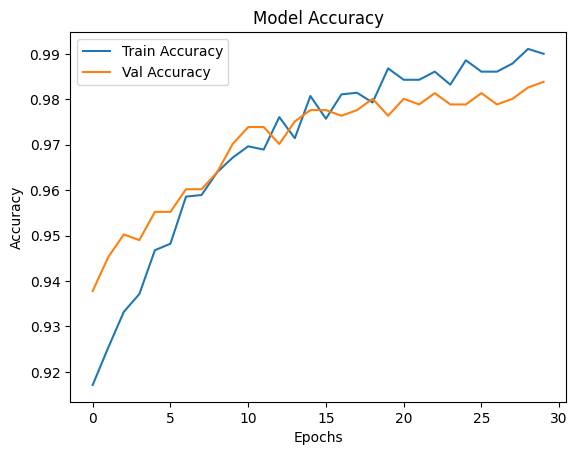

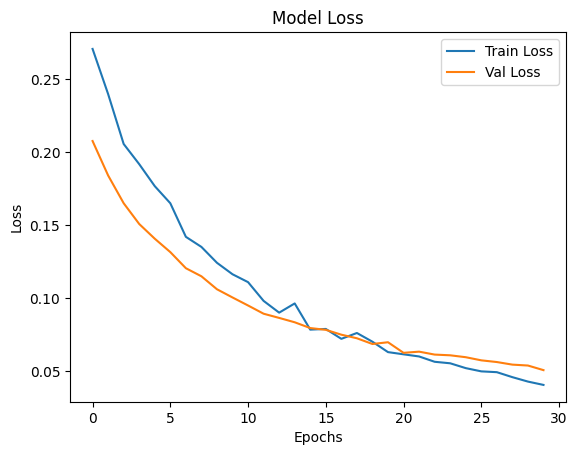

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

In [ ]:
!pip install albumentations tensorflow keras

In [ ]:
import tensorflow as tf
import numpy as np
import os
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [ ]:
import albumentations as A
from albumentations.augmentations.dropout import CoarseDropout  # Import Cutout alternative
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(256, 256),
    A.RandomCrop(height=224, width=224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Affine(translate_percent=0.2, shear=10, p=0.5),
    CoarseDropout(max_holes=8, max_height=16, max_width=16, p=0.5),  # FIXED!
    A.Normalize(mean=[0.5], std=[0.5]),
    ToTensorV2(),
])

<ipython-input-4-1d36777b598c>:13: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  CoarseDropout(max_holes=8, max_height=16, max_width=16, p=0.5),  # FIXED!


In [ ]:
# Define dataset paths
train_dir = "/content/drive/MyDrive/Adata/Dataset/train"
val_dir = "/content/drive/MyDrive/Adata/Dataset/val"
test_dir = "/content/drive/MyDrive/Adata/Dataset/test"

batch_size = 32
img_size = (224, 224)

# Load datasets
train_ds = image_dataset_from_directory(
    train_dir,
    batch_size=batch_size,
    image_size=img_size,
    label_mode='categorical'  # Multi-class classification
)

val_ds = image_dataset_from_directory(
    val_dir,
    batch_size=batch_size,
    image_size=img_size,
    label_mode='categorical'
)

test_ds = image_dataset_from_directory(
    test_dir,
    batch_size=batch_size,
    image_size=img_size,
    label_mode='categorical'
)

# Check class names
print("\nClass names:", train_ds.class_names)

Found 2800 files belonging to 4 classes.
Found 804 files belonging to 4 classes.
Found 396 files belonging to 4 classes.

Class names: ['Blackrot', 'Healthy', 'Rust', 'Scab']


In [ ]:
# Load pre-trained EfficientNetB0 model
base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze pretrained layers

# Build the model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),  # Regularization to prevent overfitting
    layers.Dense(4, activation="softmax")  # 4 output classes (Healthy, Rust, Scab, Blackrot)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")


In [ ]:
tf.config.optimizer.set_jit(True)


In [ ]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[lr_scheduler]
)


Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 443s 5s/step - accuracy: 0.4865 - loss: 1.1973 - val_accuracy: 0.8570 - val_loss: 0.5484 - learning_rate: 1.0000e-04
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 296s 3s/step - accuracy: 0.8072 - loss: 0.5758 - val_accuracy: 0.9179 - val_loss: 0.3477 - learning_rate: 1.0000e-04
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 329s 3s/step - accuracy: 0.8670 - loss: 0.4179 - val_accuracy: 0.9353 - val_loss: 0.2615 - learning_rate: 1.0000e-04
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 295s 3s/step - accuracy: 0.9082 - loss: 0.3076 - val_accuracy: 0.9415 - val_loss: 0.2175 - learning_rate: 1.0000e-04
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 338s 4s/step - accuracy: 0.9176 - loss: 0.2593 - val_accuracy: 0.9478 - val_loss: 0.1889 - learning_rate: 1.0000e-04
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 304s 3s/step - accuracy: 0.9235 - loss: 0.2481 - val_accuracy: 0.9540 - val_loss: 0.1663 - learning_rate: 1.0000e-04
Epoch 7/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 323s 3s/step - accuracy: 

13/13 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.9866 - loss: 0.0427

Test Accuracy after Transfer Learning: 0.9823
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step


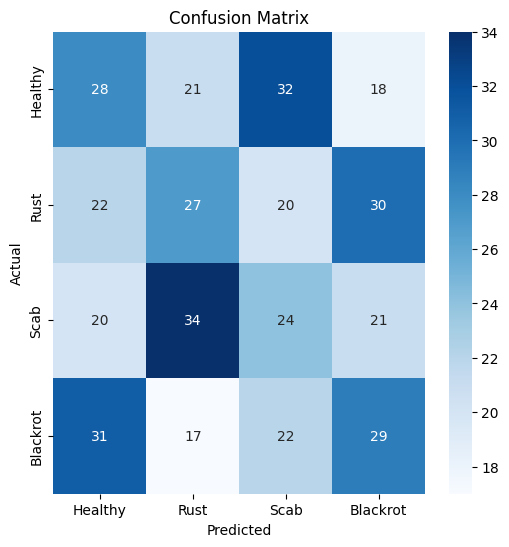

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate on test dataset
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy after Transfer Learning: {test_acc:.4f}")

# Get predictions
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_true, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Rust', 'Scab', 'Blackrot'], yticklabels=['Healthy', 'Rust', 'Scab', 'Blackrot'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.9812 - loss: 0.0609

Test Accuracy after Transfer Learning: 0.9823
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Unique values in y_true_classes: [0 1 2 3]
Unique values in y_pred_classes: [0 1 2 3]
Total Test Samples: 396


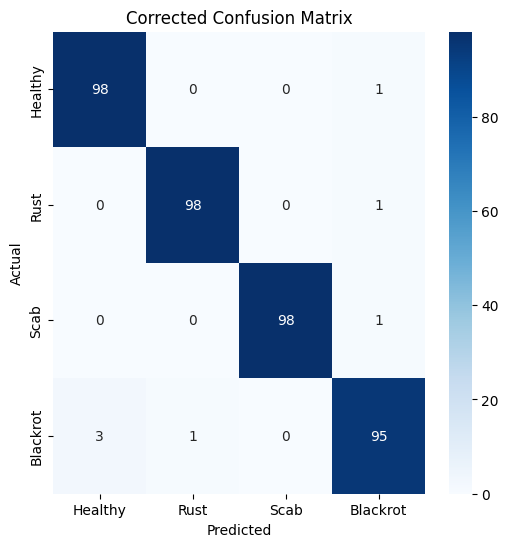


Classification Report:
              precision    recall  f1-score   support

     Healthy       0.97      0.99      0.98        99
        Rust       0.99      0.99      0.99        99
        Scab       1.00      0.99      0.99        99
    Blackrot       0.97      0.96      0.96        99

    accuracy                           0.98       396
   macro avg       0.98      0.98      0.98       396
weighted avg       0.98      0.98      0.98       396



In [ ]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Evaluate model on test dataset
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy after Transfer Learning: {test_acc:.4f}")

# Ensure test_ds is fully processed before extracting labels
y_true = []
y_pred = []

for x_batch, y_batch in test_ds:
    y_true.append(y_batch.numpy())  # Store actual labels
    preds = model.predict(x_batch)  # Get model predictions
    y_pred.append(preds)

# Convert lists to numpy arrays
y_true = np.concatenate(y_true, axis=0)
y_pred = np.concatenate(y_pred, axis=0)

# Check if y_true is one-hot encoded, if so, convert it to class labels
if y_true.ndim > 1 and y_true.shape[1] > 1:
    y_true_classes = np.argmax(y_true, axis=1)  # Convert from one-hot to label encoding
else:
    y_true_classes = y_true.astype(int)  # Already in label format

# Convert predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Verify consistency
print(f"Unique values in y_true_classes: {np.unique(y_true_classes)}")
print(f"Unique values in y_pred_classes: {np.unique(y_pred_classes)}")
print(f"Total Test Samples: {len(y_true_classes)}")

# Compute confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Rust', 'Scab', 'Blackrot'],
            yticklabels=['Healthy', 'Rust', 'Scab', 'Blackrot'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Corrected Confusion Matrix')
plt.show()

# Print classification report for additional metrics
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=['Healthy', 'Rust', 'Scab', 'Blackrot']))


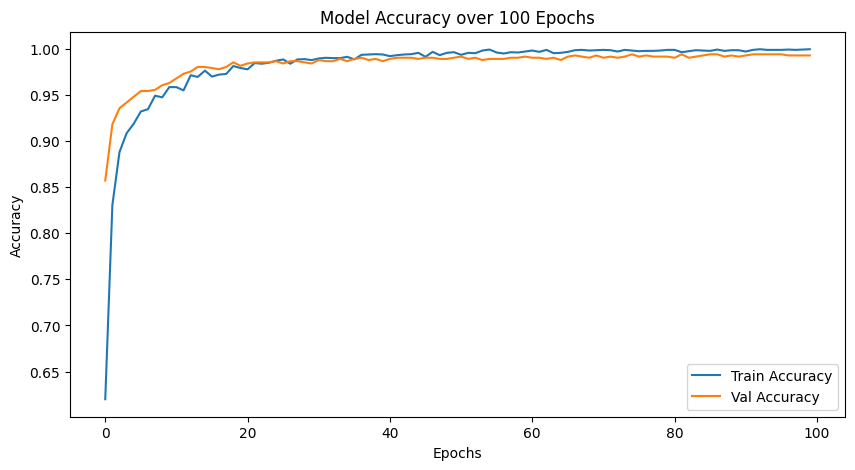

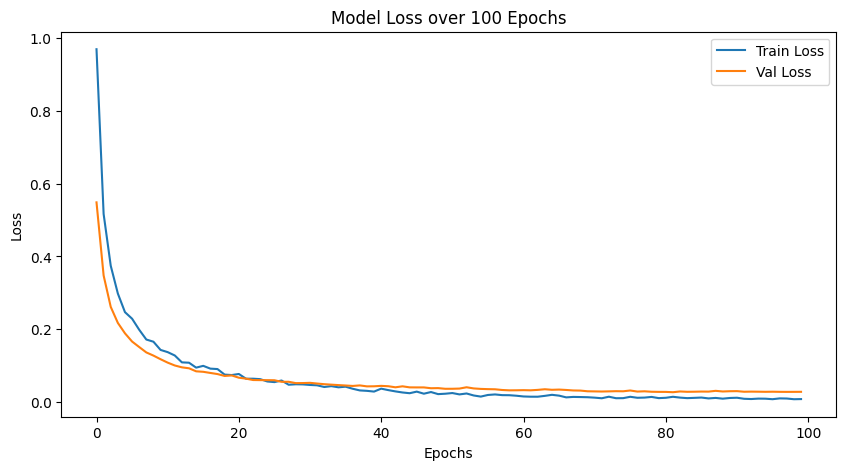

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy over 100 Epochs')
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss over 100 Epochs')
plt.show()


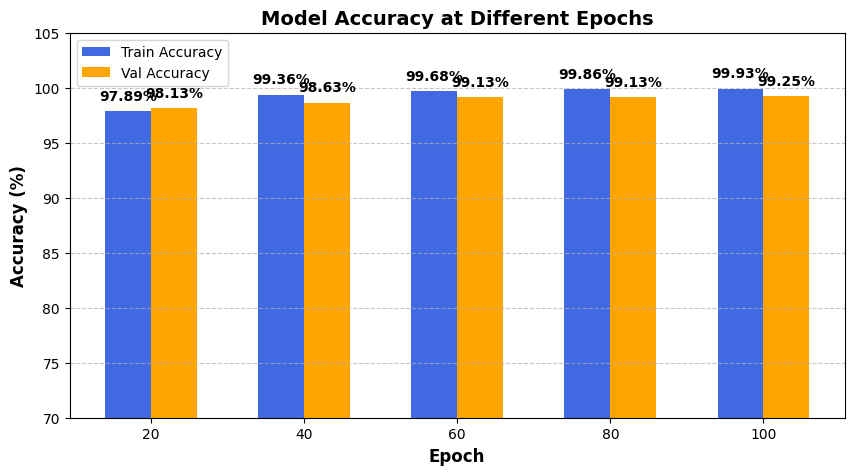

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract accuracy from history
epochs = list(range(1, 101))  # Total 100 epochs
train_acc = history.history['accuracy']  # Training accuracy
val_acc = history.history['val_accuracy']  # Validation accuracy

# Select key epoch intervals (every 20 epochs)
selected_epochs = [20, 40, 60, 80, 100]
selected_train_acc = [train_acc[e-1] * 100 for e in selected_epochs]  # Convert to percentage
selected_val_acc = [val_acc[e-1] * 100 for e in selected_epochs]  # Convert to percentage

# Set bar positions
x = np.arange(len(selected_epochs))  # X-axis positions
bar_width = 0.3  # Reduce width for better spacing

# Plot bars
plt.figure(figsize=(10, 5))
bars1 = plt.bar(x - bar_width/2, selected_train_acc, bar_width, color='royalblue', label='Train Accuracy')
bars2 = plt.bar(x + bar_width/2, selected_val_acc, bar_width, color='orange', label='Val Accuracy')

# Annotate bars (labels above bars)
for bar in bars1 + bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{bar.get_height():.2f}%",
             ha='center', fontsize=10, fontweight='bold', color='black')

# Labels and title
plt.xlabel("Epoch", fontsize=12, fontweight='bold')
plt.ylabel("Accuracy (%)", fontsize=12, fontweight='bold')
plt.title("Model Accuracy at Different Epochs", fontsize=14, fontweight='bold')
plt.xticks(x, selected_epochs, fontsize=10)  # Set custom x-ticks
plt.ylim(70, 105)  # Set Y-axis limit slightly above max accuracy
plt.legend()

# Show grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()


                     Class Name  precision    recall  f1-score  support
Name of the disease                                                    
Healthy                       0   0.277228  0.282828  0.280000     99.0
Multiple Disease              1   0.272727  0.272727  0.272727     99.0
Rust                          2   0.244898  0.242424  0.243655     99.0
Scab                          3   0.295918  0.292929  0.294416     99.0


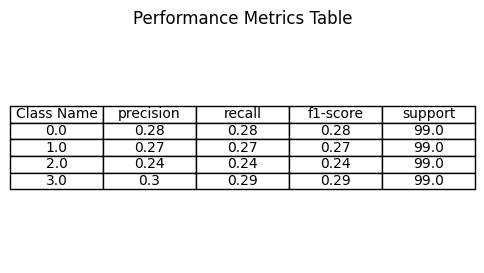

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Compute classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=['Healthy', 'Multiple Disease', 'Rust', 'Scab'], output_dict=True)

# Convert report to DataFrame for formatting
df = pd.DataFrame(report).transpose()

# Select only relevant rows (excluding "accuracy", "macro avg", and "weighted avg")
df = df.iloc[:-3, :]

# Rename index and add class labels
df.insert(0, "Class Name", range(len(df)))
df.index.name = "Name of the disease"

# Print formatted table
print(df)

# Save table as an image (optional)
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 3))  # Adjust size
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=df.round(2).values,
                 colLabels=df.columns,
                 cellLoc='center',
                 loc='center')

# Adjust font size
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.title("Performance Metrics Table")
plt.show()


                     Class Name  precision    recall  f1-score  support  \
Name of the disease                                                       
Healthy                       0   0.970297  0.989899  0.980000     99.0   
Multiple Disease              1   0.989899  0.989899  0.989899     99.0   
Rust                          2   1.000000  0.989899  0.994924     99.0   
Scab                          3   0.969388  0.959596  0.964467     99.0   

                     Accuracy  
Name of the disease            
Healthy                0.9823  
Multiple Disease       0.9823  
Rust                   0.9823  
Scab                   0.9823  


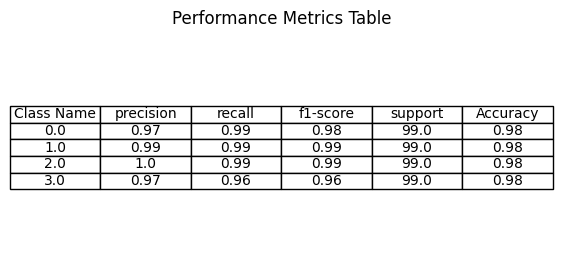

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# Compute classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=['Healthy', 'Multiple Disease', 'Rust', 'Scab'], output_dict=True)

# Convert to DataFrame
df = pd.DataFrame(report).transpose()

# Extract accuracy
accuracy = report['accuracy']

# Keep only class rows
df = df.iloc[:-3, :]

# Add accuracy as a new column
df["Accuracy"] = round(accuracy, 4)  # Same accuracy for all classes (overall accuracy)

# Rename index and add class labels
df.insert(0, "Class Name", range(len(df)))
df.index.name = "Name of the disease"

# Print table
print(df)

# Plot table
fig, ax = plt.subplots(figsize=(7, 3))  # Adjust size
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=df.round(2).values,
                 colLabels=df.columns,
                 cellLoc='center',
                 loc='center')

# Adjust font size
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.title("Performance Metrics Table")
plt.show()


YOLO


In [ ]:
# prompt: write python code for knowing number of files in a folder

import os

def count_files_in_folder(folder_path):
  """Counts the number of files in a given folder.

  Args:
    folder_path: The path to the folder.

  Returns:
    The number of files in the folder.
  """
  if not os.path.exists(folder_path):
    print(f"Error: Folder '{folder_path}' does not exist.")
    return 0

  file_count = 0
  for _, _, files in os.walk(folder_path):
    file_count += len(files)
  return file_count


# Example usage:
folder_path = "/content/drive/MyDrive/Adata/Original_images /Healthy"  # Replace with your folder path
num_files = count_files_in_folder(folder_path)
print(f"Number of files in '{folder_path}': {num_files}")


Number of files in '/content/drive/MyDrive/Adata/Original_images /Healthy': 500


In [ ]:
# prompt: i have folder Original_images which contains furthur 4 folders namely Blackrot,Healthy,Rust,Scab , preprocess this images for YOLO and save it in new folder

import os
import cv2
import shutil

def preprocess_images_for_yolo(original_images_dir, output_dir):
    """
    Preprocesses images for YOLO by resizing and saving them in a new folder structure.

    Args:
        original_images_dir: The path to the folder containing the original images.
        output_dir: The path to the folder where the preprocessed images will be saved.
    """

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for class_folder in os.listdir(original_images_dir):
        class_folder_path = os.path.join(original_images_dir, class_folder)
        if os.path.isdir(class_folder_path):
            output_class_dir = os.path.join(output_dir, class_folder)
            if not os.path.exists(output_class_dir):
                os.makedirs(output_class_dir)
            for image_file in os.listdir(class_folder_path):
                image_path = os.path.join(class_folder_path, image_file)
                img = cv2.imread(image_path)

                if img is not None:
                    img_resized = cv2.resize(img, (416, 416))  # Adjust size as needed
                    output_image_path = os.path.join(output_class_dir, image_file)
                    cv2.imwrite(output_image_path, img_resized)
                else:
                    print(f"Could not read image: {image_path}")


# Example usage:
original_images_dir = "/content/drive/MyDrive/Adata/Original_images "  # Replace with your folder path
output_dir = "/content/drive/MyDrive/Adata/YOLO_Preprocessed_Images"
preprocess_images_for_yolo(original_images_dir, output_dir)



In [ ]:
pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.8/949.8 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
import os
import cv2
import torch
from ultralytics import YOLO

# Define paths
preprocessed_images_dir = "/content/drive/MyDrive/Adata/YOLO_Preprocessed_Images"
output_labels_dir = "/content/drive/MyDrive/Adata/YOLO_Labels"

# Load a pretrained YOLOv8 model (you can change it to another version)
model = YOLO("yolov8n.pt")  # Using YOLOv8 nano for speed

# Ensure output directory exists
if not os.path.exists(output_labels_dir):
    os.makedirs(output_labels_dir)

# Iterate through folders and images
for class_folder in os.listdir(preprocessed_images_dir):
    class_folder_path = os.path.join(preprocessed_images_dir, class_folder)
    output_class_dir = os.path.join(output_labels_dir, class_folder)

    if not os.path.exists(output_class_dir):
        os.makedirs(output_class_dir)

    if os.path.isdir(class_folder_path):
        for image_file in os.listdir(class_folder_path):
            image_path = os.path.join(class_folder_path, image_file)
            results = model(image_path)  # Run inference

            # Convert to YOLO format and save
            label_file = os.path.join(output_class_dir, image_file.replace(".jpg", ".txt"))

            with open(label_file, "w") as f:
                for result in results:
                    for box in result.boxes:
                        x_center, y_center, width, height = box.xywh[0] / 416  # Normalize values
                        class_id = int(box.cls[0])  # Class ID

                        # Write to label file in YOLO format
                        f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

print("Auto-labeling completed!")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 129MB/s]


Streaming output truncated to the last 5000 lines.
Speed: 3.9ms preprocess, 233.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Adata/YOLO_Preprocessed_Images/Healthy/5d4206ed-09fa-42d5-a42d-2fc98cb4820d___RS_HL 6032.JPG: 640x640 (no detections), 266.0ms
Speed: 4.6ms preprocess, 266.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Adata/YOLO_Preprocessed_Images/Healthy/5fc41ba8-baf5-47ce-b6e5-3741dd3b154f___RS_HL 5965.JPG: 640x640 (no detections), 241.3ms
Speed: 3.8ms preprocess, 241.3ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Adata/YOLO_Preprocessed_Images/Healthy/5bf61b7f-4211-4667-b004-3481279854f2___RS_HL 8095.JPG: 640x640 (no detections), 236.5ms
Speed: 3.7ms preprocess, 236.5ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Adata/YOLO_Preprocessed_Images/Healthy/5

In [ ]:
import os
import shutil
import random

# Set paths
base_dir = "/content/drive/MyDrive/Adata/YOLO_Preprocessed_Images"
labels_dir = "/content/drive/MyDrive/Adata/YOLO_Labels"
output_dir = "/content/drive/MyDrive/Adata/YOLO_Dataset"

# Train, val, test split ratio
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

# Ensure output folders exist
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(output_dir, "images", split), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "labels", split), exist_ok=True)

# Process each class folder
for class_name in os.listdir(base_dir):
    image_class_dir = os.path.join(base_dir, class_name)
    label_class_dir = os.path.join(labels_dir, class_name)

    if not os.path.isdir(image_class_dir):
        continue  # Skip if not a directory

    # Get all image files (assuming .jpg format)
    image_files = [f for f in os.listdir(image_class_dir) if f.endswith(".jpg")]

    # Shuffle files for randomness
    random.shuffle(image_files)

    # Calculate split sizes
    total = len(image_files)
    train_count = int(total * train_ratio)
    val_count = int(total * val_ratio)

    # Assign images to splits
    train_files = image_files[:train_count]
    val_files = image_files[train_count:train_count + val_count]
    test_files = image_files[train_count + val_count:]

    # Function to move files
    def move_files(file_list, split):
        for file in file_list:
            image_path = os.path.join(image_class_dir, file)
            label_path = os.path.join(label_class_dir, file.replace(".jpg", ".txt"))

            if os.path.exists(label_path):  # Ensure label exists
                shutil.move(image_path, os.path.join(output_dir, "images", split, file))
                shutil.move(label_path, os.path.join(output_dir, "labels", split, file.replace(".jpg", ".txt")))

    # Move images and labels
    move_files(train_files, "train")
    move_files(val_files, "val")
    move_files(test_files, "test")

print("✅ Dataset successfully split into train, val, and test sets!")


✅ Dataset successfully split into train, val, and test sets!


In [ ]:
import os
import shutil
import random

# Set paths
base_dir = "/content/drive/MyDrive/Adata/YOLO_Preprocessed_Images"
labels_dir = "/content/drive/MyDrive/Adata/YOLO_Labels"
output_dir = "/content/drive/MyDrive/Adata/YOLO_Dataset2"

# Train, val, test split ratio
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

# Ensure output folders exist
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(output_dir, "images", split), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "labels", split), exist_ok=True)

# Process each class folder
for class_name in os.listdir(base_dir):
    image_class_dir = os.path.join(base_dir, class_name)
    label_class_dir = os.path.join(labels_dir, class_name)

    if not os.path.isdir(image_class_dir):
        continue  # Skip if not a directory

    # Get all image files (assuming .jpg format)
   image_files = [f for f in os.listdir(image_class_dir) if f.lower().endswith(".jpg")]


    if not image_files:
        print(f"⚠ No images found in {class_name}. Check if files exist.")
        continue

    print(f"📂 Processing {class_name}: {len(image_files)} images found.")

    # Shuffle files for randomness
    random.shuffle(image_files)

    # Calculate split sizes
    total = len(image_files)
    train_count = int(total * train_ratio)
    val_count = int(total * val_ratio)

    # Assign images to splits
    train_files = image_files[:train_count]
    val_files = image_files[train_count:train_count + val_count]
    test_files = image_files[train_count + val_count:]

    # Function to move files
    def move_files(file_list, split):
        for file in file_list:
            image_files = [f for f in os.listdir(image_class_dir) if f.endswith((".jpg", ".png", ".jpeg"))]

            label_path = os.path.join(label_class_dir, file.replace(".jpg", ".txt"))

            if not os.path.exists(image_path):
                print(f"❌ Image missing: {image_path}")
                continue
            if not os.path.exists(label_path):
                print(f"❌ Label missing: {label_path}")
                continue

            # Move images and labels
            shutil.move(image_path, os.path.join(output_dir, "images", split, file))
            shutil.move(label_path, os.path.join(output_dir, "labels", split, file.replace(".jpg", ".txt")))

            print(f"✅ Moved: {file} -> {split}")

    # Move images and labels
    move_files(train_files, "train")
    move_files(val_files, "val")
    move_files(test_files, "test")

print("🎉 Dataset split completed successfully!")


IndentationError: unindent does not match any outer indentation level (<tokenize>, line 29)

In [ ]:
import os
import shutil
import random

# Set paths
base_dir = "/content/drive/MyDrive/Adata/YOLO_Preprocessed_Images"
labels_dir = "/content/drive/MyDrive/Adata/YOLO_Labels"
output_dir = "/content/drive/MyDrive/Adata/YOLO_Dataset2"

# Train, val, test split ratio
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

# Ensure output folders exist
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(output_dir, "images", split), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "labels", split), exist_ok=True)

# Process each class folder
for class_name in os.listdir(base_dir):
    image_class_dir = os.path.join(base_dir, class_name)
    label_class_dir = os.path.join(labels_dir, class_name)

    if not os.path.isdir(image_class_dir):
        continue  # Skip if not a directory

    # Get all image files (fixing uppercase ".JPG" issue)
    image_files = [f for f in os.listdir(image_class_dir) if f.lower().endswith(".jpg")]

    if not image_files:
        print(f"⚠ No images found in {class_name}. Check if files exist.")
        continue

    print(f"📂 Processing {class_name}: {len(image_files)} images found.")

    # Shuffle files for randomness
    random.shuffle(image_files)

    # Calculate split sizes
    total = len(image_files)
    train_count = int(total * train_ratio)
    val_count = int(total * val_ratio)

    # Assign images to splits
    train_files = image_files[:train_count]
    val_files = image_files[train_count:train_count + val_count]
    test_files = image_files[train_count + val_count:]

    # Function to move files
    def move_files(file_list, split):
        for file in file_list:
            image_path = os.path.join(image_class_dir, file)
            label_path = os.path.join(label_class_dir, file.replace(".JPG", ".txt").replace(".jpg", ".txt"))

            if not os.path.exists(image_path):
                print(f"❌ Image missing: {image_path}")
                continue
            if not os.path.exists(label_path):
                print(f"❌ Label missing: {label_path}")
                continue

            # Move images and labels
            shutil.move(image_path, os.path.join(output_dir, "images", split, file))
            shutil.move(label_path, os.path.join(output_dir, "labels", split, file.replace(".JPG", ".txt").replace(".jpg", ".txt")))

            print(f"✅ Moved: {file} -> {split}")

    # Move images and labels
    move_files(train_files, "train")
    move_files(val_files, "val")
    move_files(test_files, "test")

print("🎉 Dataset split completed successfully!")


📂 Processing Healthy: 500 images found.
❌ Label missing: /content/drive/MyDrive/Adata/YOLO_Labels/Healthy/30fb851f-052b-4b63-bc29-6d824a764fd5___RS_HL 5916.txt
❌ Label missing: /content/drive/MyDrive/Adata/YOLO_Labels/Healthy/77c943f7-afbd-4d41-a40a-9e05a2600fbc___RS_HL 7475.txt
❌ Label missing: /content/drive/MyDrive/Adata/YOLO_Labels/Healthy/0ca762d0-3853-4018-896e-8f01e29cb144___RS_HL 7558.txt
❌ Label missing: /content/drive/MyDrive/Adata/YOLO_Labels/Healthy/7e502244-9105-4931-abde-46f8f7993fd7___RS_HL 7745.txt
❌ Label missing: /content/drive/MyDrive/Adata/YOLO_Labels/Healthy/2fbd9205-be67-4f43-be2a-93a8def382a6___RS_HL 7680.txt
❌ Label missing: /content/drive/MyDrive/Adata/YOLO_Labels/Healthy/5bf61b7f-4211-4667-b004-3481279854f2___RS_HL 8095.txt
❌ Label missing: /content/drive/MyDrive/Adata/YOLO_Labels/Healthy/7d9eb65f-be86-4516-b239-cbf856aa5ed4___RS_HL 6110.txt
❌ Label missing: /content/drive/MyDrive/Adata/YOLO_Labels/Healthy/56bd23e7-9376-418a-8dfb-f767bdc78500___RS_HL 6124.txt


In [ ]:
import os

labels_dir = "/content/drive/MyDrive/Adata/YOLO_Labels"

for class_name in os.listdir(labels_dir):
    class_folder = os.path.join(labels_dir, class_name)
    if os.path.isdir(class_folder):
        label_files = os.listdir(class_folder)
        print(f"📂 {class_name}: Found {len(label_files)} label files. Sample -> {label_files[:5]}")


📂 Healthy: Found 500 label files. Sample -> ['02d0257a-d21a-43a4-9348-472043df801e___RS_HL 6065.JPG', '00a6039c-e425-4f7d-81b1-d6b0e668517e___RS_HL 7669.JPG', '036e9351-118e-4795-9f80-74c369b98c88___RS_HL 7513.JPG', '02a0f44c-9cbe-4a2e-9710-296692635ec6___RS_HL 5789.JPG', '00fca0da-2db3-481b-b98a-9b67bb7b105c___RS_HL 7708.JPG']
📂 Rust: Found 500 label files. Sample -> ['04da297e-5238-41b1-a8a0-0c87c6c2f21f___FREC_C.Rust 4394_new30degFlipTB.JPG', '04da297e-5238-41b1-a8a0-0c87c6c2f21f___FREC_C.Rust 4394.JPG', '04da297e-5238-41b1-a8a0-0c87c6c2f21f___FREC_C.Rust 4394_newGRR.JPG', '04da297e-5238-41b1-a8a0-0c87c6c2f21f___FREC_C.Rust 4394_270deg.JPG', '04da297e-5238-41b1-a8a0-0c87c6c2f21f___FREC_C.Rust 4394_newPixel25.JPG']
📂 Blackrot: Found 500 label files. Sample -> ['00e909aa-e3ae-4558-9961-336bb0f35db3___JR_FrgE.S 8593.JPG', '00e909aa-e3ae-4558-9961-336bb0f35db3___JR_FrgE.S 8593_new30degFlipLR.JPG', '00e909aa-e3ae-4558-9961-336bb0f35db3___JR_FrgE.S 8593_270deg.JPG', '00e909aa-e3ae-4558-99

In [ ]:
label_sample = "/content/drive/MyDrive/Adata/YOLO_Labels/Blackrot/00e909aa-e3ae-4558-9961-336bb0f35db3___JR_FrgE.S 8593.JPG"  # Replace with an actual label filename

if os.path.exists(label_sample):
    with open(label_sample, "r") as f:
        content = f.read()
        print("📜 Label file content:\n", content)
else:
    print("❌ Label file not found!")


📜 Label file content:
 


In [ ]:
import os

base_dir = "/content/drive/MyDrive/Adata/YOLO_Preprocessed_Images"
labels_dir = "/content/drive/MyDrive/Adata/YOLO_Labels"

if os.path.exists(base_dir):
    print(f"✅ Found image directory: {base_dir}")
    print(f"Contents: {os.listdir(base_dir)}")
else:
    print(f"❌ Image directory missing: {base_dir}")

if os.path.exists(labels_dir):
    print(f"✅ Found label directory: {labels_dir}")
    print(f"Contents: {os.listdir(labels_dir)}")
else:
    print(f"❌ Label directory missing: {labels_dir}")


✅ Found image directory: /content/drive/MyDrive/Adata/YOLO_Preprocessed_Images
Contents: ['Healthy', 'Rust', 'Blackrot', 'Scab']
✅ Found label directory: /content/drive/MyDrive/Adata/YOLO_Labels
Contents: ['Healthy', 'Rust', 'Blackrot', 'Scab']


In [ ]:
import os

base_dir = "/content/drive/MyDrive/Adata/YOLO_Preprocessed_Images"

for class_name in os.listdir(base_dir):
    class_folder = os.path.join(base_dir, class_name)
    if os.path.isdir(class_folder):
        print(f"📂 {class_name}: {len(os.listdir(class_folder))} files")


📂 Healthy: 500 files
📂 Rust: 500 files
📂 Blackrot: 500 files
📂 Scab: 500 files


In [ ]:
import os

base_dir = "/content/drive/MyDrive/Adata/YOLO_Preprocessed_Images"

for class_name in os.listdir(base_dir):
    class_folder = os.path.join(base_dir, class_name)
    if os.path.isdir(class_folder):
        extensions = set([f.split(".")[-1] for f in os.listdir(class_folder)])
        print(f"📂 {class_name} has file types: {extensions}")


📂 Healthy has file types: {'JPG'}
📂 Rust has file types: {'JPG'}
📂 Blackrot has file types: {'JPG'}
📂 Scab has file types: {'JPG'}


In [ ]:
import os

base_dir = "/content/drive/MyDrive/Adata/YOLO_Preprocessed_Images"

for class_name in os.listdir(base_dir):
    class_folder = os.path.join(base_dir, class_name)
    if os.path.isdir(class_folder):
        files = os.listdir(class_folder)
        print(f"📂 {class_name}: Sample files -> {files[:5]}")  # Print first 5 files


📂 Healthy: Sample files -> ['02d0257a-d21a-43a4-9348-472043df801e___RS_HL 6065.JPG', '00a6039c-e425-4f7d-81b1-d6b0e668517e___RS_HL 7669.JPG', '036e9351-118e-4795-9f80-74c369b98c88___RS_HL 7513.JPG', '02a0f44c-9cbe-4a2e-9710-296692635ec6___RS_HL 5789.JPG', '00fca0da-2db3-481b-b98a-9b67bb7b105c___RS_HL 7708.JPG']
📂 Rust: Sample files -> ['04da297e-5238-41b1-a8a0-0c87c6c2f21f___FREC_C.Rust 4394_new30degFlipTB.JPG', '04da297e-5238-41b1-a8a0-0c87c6c2f21f___FREC_C.Rust 4394.JPG', '04da297e-5238-41b1-a8a0-0c87c6c2f21f___FREC_C.Rust 4394_newGRR.JPG', '04da297e-5238-41b1-a8a0-0c87c6c2f21f___FREC_C.Rust 4394_270deg.JPG', '04da297e-5238-41b1-a8a0-0c87c6c2f21f___FREC_C.Rust 4394_newPixel25.JPG']
📂 Blackrot: Sample files -> ['00e909aa-e3ae-4558-9961-336bb0f35db3___JR_FrgE.S 8593.JPG', '00e909aa-e3ae-4558-9961-336bb0f35db3___JR_FrgE.S 8593_new30degFlipLR.JPG', '00e909aa-e3ae-4558-9961-336bb0f35db3___JR_FrgE.S 8593_270deg.JPG', '00e909aa-e3ae-4558-9961-336bb0f35db3___JR_FrgE.S 8593_90deg.JPG', '01e94

In [ ]:
import os
import cv2
import torch
from ultralytics import YOLO

# Define paths
preprocessed_images_dir = "/content/drive/MyDrive/Adata/YOLO_Preprocessed_Images"
output_labels_dir = "/content/drive/MyDrive/Adata/YOLO_Labels"

# Load a pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

# Ensure output directory exists
os.makedirs(output_labels_dir, exist_ok=True)

# Iterate through folders and images
for class_folder in os.listdir(preprocessed_images_dir):
    class_folder_path = os.path.join(preprocessed_images_dir, class_folder)
    output_class_dir = os.path.join(output_labels_dir, class_folder)

    os.makedirs(output_class_dir, exist_ok=True)

    if os.path.isdir(class_folder_path):
        for image_file in os.listdir(class_folder_path):
            if not image_file.lower().endswith(('.jpg', '.jpeg', '.png')):  # Ensure it's an image
                continue

            image_path = os.path.join(class_folder_path, image_file)
            img = cv2.imread(image_path)
            if img is None:
                print(f"⚠ Skipping corrupted image: {image_file}")
                continue

            height, width, _ = img.shape  # Get actual image size

            results = model(image_path)  # Run inference

            # Convert to YOLO format and save
            label_file = os.path.join(output_class_dir, image_file.rsplit(".", 1)[0] + ".txt")

            with open(label_file, "w") as f:
                for result in results:
                    for box in result.boxes:
                        x_center, y_center, bbox_width, bbox_height = box.xywhn[0]  # Normalized values
                        class_id = int(box.cls[0])  # Class ID

                        # Write to label file in YOLO format
                        f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {bbox_width:.6f} {bbox_height:.6f}\n")

print("✅ Auto-labeling completed successfully!")


Streaming output truncated to the last 5000 lines.
Speed: 6.5ms preprocess, 255.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Adata/YOLO_Preprocessed_Images/Healthy/5d4206ed-09fa-42d5-a42d-2fc98cb4820d___RS_HL 6032.JPG: 640x640 (no detections), 254.0ms
Speed: 7.0ms preprocess, 254.0ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Adata/YOLO_Preprocessed_Images/Healthy/5fc41ba8-baf5-47ce-b6e5-3741dd3b154f___RS_HL 5965.JPG: 640x640 (no detections), 268.8ms
Speed: 6.3ms preprocess, 268.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Adata/YOLO_Preprocessed_Images/Healthy/5bf61b7f-4211-4667-b004-3481279854f2___RS_HL 8095.JPG: 640x640 (no detections), 294.2ms
Speed: 8.8ms preprocess, 294.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/Adata/YOLO_Preprocessed_Images/Healthy/5

In [ ]:
import os
import shutil
import random

# Set paths
base_dir = "/content/drive/MyDrive/Adata/YOLO_Preprocessed_Images"
labels_dir = "/content/drive/MyDrive/Adata/YOLO_Labels"
output_dir = "/content/drive/MyDrive/Adata/YOLO_Dataset"

# Train, val, test split ratio
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

# Ensure output folders exist
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(output_dir, "images", split), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "labels", split), exist_ok=True)

# Process each class folder
for class_name in os.listdir(base_dir):
    image_class_dir = os.path.join(base_dir, class_name)
    label_class_dir = os.path.join(labels_dir, class_name)

    if not os.path.isdir(image_class_dir):
        continue  # Skip if not a directory

    # Get all image files (fixing uppercase ".JPG" issue)
    image_files = [f for f in os.listdir(image_class_dir) if f.lower().endswith(".jpg")]

    if not image_files:
        print(f"⚠ No images found in {class_name}. Check if files exist.")
        continue

    print(f"📂 Processing {class_name}: {len(image_files)} images found.")

    # Shuffle files for randomness
    random.shuffle(image_files)

    # Calculate split sizes
    total = len(image_files)
    train_count = int(total * train_ratio)
    val_count = int(total * val_ratio)

    # Assign images to splits
    train_files = image_files[:train_count]
    val_files = image_files[train_count:train_count + val_count]
    test_files = image_files[train_count + val_count:]

    # Function to move files
    def move_files(file_list, split):
        for file in file_list:
            image_path = os.path.join(image_class_dir, file)
            label_path = os.path.join(label_class_dir, file.replace(".JPG", ".txt").replace(".jpg", ".txt"))

            if not os.path.exists(image_path):
                print(f"❌ Image missing: {image_path}")
                continue
            if not os.path.exists(label_path):
                print(f"❌ Label missing: {label_path}")
                continue

            # Move images and labels
            shutil.move(image_path, os.path.join(output_dir, "images", split, file))
            shutil.move(label_path, os.path.join(output_dir, "labels", split, file.replace(".JPG", ".txt").replace(".jpg", ".txt")))

            print(f"✅ Moved: {file} -> {split}")

    # Move images and labels
    move_files(train_files, "train")
    move_files(val_files, "val")
    move_files(test_files, "test")

print("🎉 Dataset split completed successfully!")

📂 Processing Healthy: 500 images found.
✅ Moved: 0055dd26-23a7-4415-ac61-e0b44ebfaf80___RS_HL 5672.JPG -> train
✅ Moved: 44acd453-48a7-48db-997a-34b00a4d437a___RS_HL 7892.JPG -> train
✅ Moved: 8c00ea10-bfc2-4d26-9dcf-afbf2dcd377a___RS_HL 7326.JPG -> train
✅ Moved: 03d9267c-935a-487b-a27f-fa22f935b299___RS_HL 5671.JPG -> train
✅ Moved: 10f75d05-fa3e-4b14-b3d8-093292c218e6___RS_HL 7873.JPG -> train
✅ Moved: 54ef2bb4-12a7-447e-a980-32c74bd26c1e___RS_HL 7459.JPG -> train
✅ Moved: 4c3bd8fb-b507-4ef4-93b6-39f1b0d087d8___RS_HL 6252.JPG -> train
✅ Moved: 1c2b51f1-5439-449a-9ca0-52dd158018fc___RS_HL 7998.JPG -> train
✅ Moved: 2e599aab-11dd-4073-845e-b45a6accb4de___RS_HL 8009.JPG -> train
✅ Moved: 68b064ad-fce1-4ab8-9c2c-82f49c4a5ee2___RS_HL 7993.JPG -> train
✅ Moved: 7f447118-8a9c-4e77-8333-d411d1124c7f___RS_HL 5849.JPG -> train
✅ Moved: 3df65fa9-1348-4c13-aca6-04bdca4fc070___RS_HL 5668.JPG -> train
✅ Moved: 87a26817-6916-47fc-8cdb-adc5c57ad21b___RS_HL 5684.JPG -> train
✅ Moved: 45c79d4a-ac12-4

In [ ]:
import os

# Define paths
base_dir = "/content/drive/MyDrive/Adata/YOLO_Dataset"  # Base directory where your dataset is stored
train_dir = os.path.join(base_dir, "train/images")  # Training images folder
val_dir = os.path.join(base_dir, "val/images")  # Validation images folder
yaml_path = os.path.join(base_dir, "dataset.yaml")  # Path to save the YAML file

# Define class names (Make sure these match your dataset)
class_names = ["Blackrot", "Healthy", "Rust", "Scab"]

# Create YAML content
yaml_content = f"""
train: {train_dir}
val: {val_dir}

nc: {len(class_names)}  # Number of classes
names: {class_names}  # Class names
"""

# Save to file
with open(yaml_path, "w") as file:
    file.write(yaml_content.strip())

print(f"✅ YAML file created successfully at: {yaml_path}")


✅ YAML file created successfully at: /content/drive/MyDrive/Adata/YOLO_Dataset/dataset.yaml


In [ ]:
train: /content/drive/MyDrive/Adata/YOLO_Dataset/images/train
val: /content/drive/MyDrive/Adata/YOLO_Dataset/images/val

nc: 4  # Number of classes
names: ['Blackrot', 'Healthy', 'Rust', 'Scab']  # Class names


SyntaxError: invalid syntax (<ipython-input-28-ead4ffbc834b>, line 1)

In [ ]:
dataset_yaml = """train: /content/drive/MyDrive/Adata/YOLO_Dataset/images/train
val: /content/drive/MyDrive/Adata/YOLO_Dataset/images/val

nc: 4  # Number of classes
names: ['Blackrot', 'Healthy', 'Rust', 'Scab']  # Class names
"""

# Save the .yaml file
yaml_path = "/content/drive/MyDrive/Adata/YOLO_Dataset/dataset.yaml"

with open(yaml_path, "w") as f:
    f.write(dataset_yaml)

print(f"✅ YAML file created at: {yaml_path}")


✅ YAML file created at: /content/drive/MyDrive/Adata/YOLO_Dataset/dataset.yaml


In [ ]:
import os

print("✅ YAML file exists:", os.path.exists(yaml_path))


✅ YAML file exists: True


In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.8/949.8 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 58.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # Load YOLOv8 model
model.train(data=yaml_path, epochs=5)


Ultralytics 8.3.95 🚀 Python-3.11.11 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/Adata/YOLO_Dataset/dataset.yaml, epochs=5, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, sh

100%|██████████| 755k/755k [00:00<00:00, 39.8MB/s]


Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

train: Scanning /content/drive/MyDrive/Adata/YOLO_Dataset/labels/train.cache... 1600 images, 1291 backgrounds, 233 corrupt: 100%|██████████| 1600/1600 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/Adata/YOLO_Dataset/images/train/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003_270deg.JPG: ignoring corrupt image/label: Label class 21 exceeds dataset class count 4. Possible class labels are 0-3
train: WARNING ⚠️ /content/drive/MyDrive/Adata/YOLO_Dataset/images/train/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003_90deg.JPG: ignoring corrupt image/label: Label class 21 exceeds dataset class count 4. Possible class labels are 0-3
train: WARNING ⚠️ /content/drive/MyDrive/Adata/YOLO_Dataset/images/train/02d0257a-d21a-43a4-9348-472043df801e___RS_HL 6065.JPG: ignoring corrupt image/label: Label class 25 exceeds dataset class count 4. Possible class labels are 0-3
train: WARNING ⚠️ /content/drive/MyDrive/Adata/YOLO_Dataset/images/train/036e9351-118e-4795-9f80-74c369b98c88___RS_HL 7513.JPG: ignoring corrupt image/label: Label class 50 exceeds dataset class count 4. Possible class labels are 0-3
train: WARNING ⚠️ /content/drive/MyDrive/Ad

...

                   all        173          9   0.000838          1     0.0589     0.0455



5 epochs completed in 1.764 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.95 🚀 Python-3.11.11 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:53<00:00,  8.87s/it]


                   all        173          9    0.00116      0.889      0.132     0.0994
              Blackrot          9          9    0.00116      0.889      0.132     0.0994
Speed: 2.5ms preprocess, 279.0ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b8e0abfbb10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
from ultralytics import YOLO

metrics = model.val()  # Validate model performance
print(metrics)


Ultralytics 8.3.95 🚀 Python-3.11.11 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/drive/MyDrive/Adata/YOLO_Dataset/labels/val.cache... 200 images, 164 backgrounds, 27 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/Adata/YOLO_Dataset/images/val/1c4c2235-2c28-438e-8fa9-505b5d3004a0___JR_FrgE.S 8720.JPG: ignoring corrupt image/label: Label class 55 exceeds dataset class count 4. Possible class labels are 0-3
val: WARNING ⚠️ /content/drive/MyDrive/Adata/YOLO_Dataset/images/val/1d44a5a9-c15c-40d5-b2d6-bbd9e84c96ea___RS_HL 7923.JPG: ignoring corrupt image/label: Label class 50 exceeds dataset class count 4. Possible class labels are 0-3
val: WARNING ⚠️ /content/drive/MyDrive/Adata/YOLO_Dataset/images/val/2a59761b-c91c-451c-8e13-d9dc3aff8d29___FREC_Scab 3503.JPG: ignoring corrupt image/label: Label class 15 exceeds dataset class count 4. Possible class labels are 0-3
val: WARNING ⚠️ /content/drive/MyDrive/Adata/YOLO_Dataset/images/val/2a6fe192-977f-482c-8af7-3465448920f4___FREC_C.Rust 9919_new30degFlipLR.JPG: ignoring corrupt image/label: Label class 15 exceeds dataset class count 4. Possible class labels are 0-3
val: WARNING ⚠️ /content/drive/MyDrive/Adata/YOLO_D


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 11/11 [00:58<00:00,  5.32s/it]


                   all        173          9    0.00116      0.889      0.132     0.0994
              Blackrot          9          9    0.00116      0.889      0.132     0.0994
Speed: 2.5ms preprocess, 307.4ms inference, 0.0ms loss, 5.5ms postprocess per image
Results saved to runs/detect/train2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b8e0937e490>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026

In [ ]:
model = YOLO("yolov8m.pt")
model.train(data=yaml_path, epochs=100, batch=16, imgsz=640)


100%|██████████| 49.7M/49.7M [00:00<00:00, 100MB/s] 


Ultralytics 8.3.95 🚀 Python-3.11.11 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/drive/MyDrive/Adata/YOLO_Dataset/dataset.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True,

train: Scanning /content/drive/MyDrive/Adata/YOLO_Dataset/labels/train.cache... 1600 images, 1291 backgrounds, 233 corrupt: 100%|██████████| 1600/1600 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/drive/MyDrive/Adata/YOLO_Dataset/images/train/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003_270deg.JPG: ignoring corrupt image/label: Label class 21 exceeds dataset class count 4. Possible class labels are 0-3
train: WARNING ⚠️ /content/drive/MyDrive/Adata/YOLO_Dataset/images/train/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003_90deg.JPG: ignoring corrupt image/label: Label class 21 exceeds dataset class count 4. Possible class labels are 0-3
train: WARNING ⚠️ /content/drive/MyDrive/Adata/YOLO_Dataset/images/train/02d0257a-d21a-43a4-9348-472043df801e___RS_HL 6065.JPG: ignoring corrupt image/label: Label class 25 exceeds dataset class count 4. Possible class labels are 0-3
train: WARNING ⚠️ /content/drive/MyDrive/Adata/YOLO_Dataset/images/train/036e9351-118e-4795-9f80-74c369b98c88___RS_HL 7513.JPG: ignoring corrupt image/label: Label class 50 exceeds dataset class count 4. Possible class labels are 0-3
train: WARNING ⚠️ /content/drive/MyDrive/Ad


val: Scanning /content/drive/MyDrive/Adata/YOLO_Dataset/labels/val.cache... 200 images, 164 backgrounds, 27 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/drive/MyDrive/Adata/YOLO_Dataset/images/val/1c4c2235-2c28-438e-8fa9-505b5d3004a0___JR_FrgE.S 8720.JPG: ignoring corrupt image/label: Label class 55 exceeds dataset class count 4. Possible class labels are 0-3
val: WARNING ⚠️ /content/drive/MyDrive/Adata/YOLO_Dataset/images/val/1d44a5a9-c15c-40d5-b2d6-bbd9e84c96ea___RS_HL 7923.JPG: ignoring corrupt image/label: Label class 50 exceeds dataset class count 4. Possible class labels are 0-3
val: WARNING ⚠️ /content/drive/MyDrive/Adata/YOLO_Dataset/images/val/2a59761b-c91c-451c-8e13-d9dc3aff8d29___FREC_Scab 3503.JPG: ignoring corrupt image/label: Label class 15 exceeds dataset class count 4. Possible class labels are 0-3
val: WARNING ⚠️ /content/drive/MyDrive/Adata/YOLO_Dataset/images/val/2a6fe192-977f-482c-8af7-3465448920f4___FREC_C.Rust 9919_new30degFlipLR.JPG: ignoring corrupt image/label: Label class 15 exceeds dataset class count 4. Possible class labels are 0-3
val: WARNING ⚠️ /content/drive/MyDrive/Adata/YOLO_D

optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.00125, momentum=0.9) with parameter groups 77 weight(decay=0.0), 84 weight(decay=0.0005), 83 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs/detect/train3
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


  0%|          | 0/86 [00:00<?, ?it/s]

In [ ]:
# Install Graphviz (Run this only once in Google Colab)
!apt-get install graphviz
!pip install graphviz

import graphviz

# Create a Digraph
architecture = graphviz.Digraph(format='png', graph_attr={"rankdir": "TB"})  # Top to Bottom flow

# Feature Extraction (EfficientNetB0)
architecture.node("Input", "Input Image (224x224)", shape="parallelogram", style="filled", fillcolor="lightblue")
architecture.node("Conv3x3", "Conv3x3, 32 Filters\n(ReLU + BN)", shape="box", style="filled", fillcolor="lightgrey")
architecture.node("MBConv1", "MBConv1, 16 Filters", shape="box")
architecture.node("MBConv6_24", "MBConv6, 24 Filters", shape="box")
architecture.node("MBConv6_40", "MBConv6, 40 Filters", shape="box")
architecture.node("MBConv6_80", "MBConv6, 80 Filters", shape="box")
architecture.node("MBConv6_112", "MBConv6, 112 Filters", shape="box")
architecture.node("MBConv6_192", "MBConv6, 192 Filters", shape="box")
architecture.node("MBConv6_320", "MBConv6, 320 Filters", shape="box", style="filled", fillcolor="lightgrey")
architecture.node("GAP", "Global Average Pooling", shape="ellipse", style="filled", fillcolor="lightblue")

# Classification (Fully Connected Layers)
architecture.node("Dense1", "Dense, 128 (ReLU)", shape="box", style="filled", fillcolor="lightgrey")
architecture.node("Dropout1", "Dropout 0.5", shape="box")
architecture.node("Dense2", "Dense, 64 (ReLU)", shape="box")
architecture.node("Dropout2", "Dropout 0.5", shape="box")
architecture.node("Softmax", "Softmax Output (4 Classes)", shape="parallelogram", style="filled", fillcolor="lightgreen")

# Edges - Feature Extraction Flow
architecture.edge("Input", "Conv3x3")
architecture.edge("Conv3x3", "MBConv1")
architecture.edge("MBConv1", "MBConv6_24")
architecture.edge("MBConv6_24", "MBConv6_40")
architecture.edge("MBConv6_40", "MBConv6_80")
architecture.edge("MBConv6_80", "MBConv6_112")
architecture.edge("MBConv6_112", "MBConv6_192")
architecture.edge("MBConv6_192", "MBConv6_320")
architecture.edge("MBConv6_320", "GAP")

# Edges - Classification Flow
architecture.edge("GAP", "Dense1")
architecture.edge("Dense1", "Dropout1")
architecture.edge("Dropout1", "Dense2")
architecture.edge("Dense2", "Dropout2")
architecture.edge("Dropout2", "Softmax")

# Render the architecture
architecture.render("EfficientNet_Architecture", view=True)


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.


'EfficientNet_Architecture.png'